# Retrain wb03b Attention-Only Model

## 0. Configuration and Reproducibility

In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")
import json, random, time, warnings
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_recall_curve, confusion_matrix,
)
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import (
    SAGEConv, GATv2Conv,
    global_max_pool, GlobalAttention,
    JumpingKnowledge,
)
from torch_geometric.utils import to_undirected

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Reproducibility ──────────────────────────────────────────────
RNG_SEED = 7
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RNG_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

# ── Paths (same as wb03b notebook) ───────────────────────────────
PROJECT_ROOT  = Path.cwd()
DATA_DIR      = PROJECT_ROOT / "DATA"
PROCESSED     = DATA_DIR / "processed"
ARRAYS_DIR    = PROCESSED / "arrays"
ARTIFACTS_DIR = PROCESSED / "artifacts"
PACK_DIR      = ARTIFACTS_DIR / "packed"
RESULTS_DIR   = PROJECT_ROOT / "results"
WB03B_DIR     = RESULTS_DIR / "wb03b"
WB03B_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU:    {torch.cuda.get_device_name(0)}")
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  Memory: {mem_gb:.1f} GB")

# ── Training settings (same as wb03b) ────────────────────────────
MAX_EPOCHS = 80
PATIENCE   = 15
BATCH_SIZE = 256

print(f"\nMax epochs: {MAX_EPOCHS}  Patience: {PATIENCE}  Batch: {BATCH_SIZE}")
print(f"Seed: {RNG_SEED}")

Device: cuda
  GPU:    NVIDIA GeForce RTX 4070 Laptop GPU
  Memory: 8.2 GB

Max epochs: 80  Patience: 15  Batch: 256
Seed: 7


## 1. Load Preprocessed Artifacts

In [2]:
# Core arrays
X = np.load(ARRAYS_DIR / "node_features.npy")
subgraph_labels = {
    int(k): v for k, v in
    json.loads((ARTIFACTS_DIR / "subgraph_labels.json").read_text()).items()
}
splits = json.loads((ARTIFACTS_DIR / "splits.json").read_text())

# Packed index arrays (from Wb02)
nodes_pack        = np.load(PACK_DIR / "nodes_by_ccid.npz")
edges_pack        = np.load(PACK_DIR / "edges_by_ccid.npz")
unique_cc         = nodes_pack["unique_cc"].astype(np.int64)
node_ptr          = nodes_pack["node_ptr"].astype(np.int64)
node_row_perm     = nodes_pack["node_row_perm"].astype(np.int64)
unique_cc_edges   = edges_pack["unique_cc_edges"].astype(np.int64)
edge_ptr          = edges_pack["edge_ptr"].astype(np.int64)
edge_src_row_perm = edges_pack["edge_src_row_perm"].astype(np.int64)
edge_dst_row_perm = edges_pack["edge_dst_row_perm"].astype(np.int64)

ccid_to_i  = {int(c): i for i, c in enumerate(unique_cc)}
ccid_to_ei = {int(c): i for i, c in enumerate(unique_cc_edges)}

def label_to_int(lbl):
    return 1 if str(lbl).lower() in {"suspicious", "illicit"} else 0

y_by_cc = {int(c): label_to_int(subgraph_labels[int(c)]) for c in unique_cc}

print(f"Nodes: {X.shape[0]:,}  Features: {X.shape[1]}")
print(f"Subgraphs: {len(unique_cc):,}  "
      f"Suspicious: {sum(y_by_cc.values()):,} "
      f"({100*sum(y_by_cc.values())/len(unique_cc):.2f}%)")

Nodes: 444,521  Features: 43
Subgraphs: 121,810  Suspicious: 2,763 (2.27%)


## 2. Dataset and Data Loaders

In [3]:
class Elliptic2SubgraphDataset(torch.utils.data.Dataset):
    """Lazy PyG dataset."""

    def __init__(self, ccids, make_undirected=True):
        self.ccids = np.asarray(ccids, dtype=np.int64)
        self.make_undirected = make_undirected

    def __len__(self):
        return self.ccids.shape[0]

    def __getitem__(self, idx):
        ccid = int(self.ccids[idx])
        i    = ccid_to_i[ccid]
        rows = node_row_perm[node_ptr[i] : node_ptr[i + 1]]
        x    = torch.from_numpy(X[rows]).float()

        local = {int(r): j for j, r in enumerate(rows.tolist())}

        if ccid in ccid_to_ei:
            ei = ccid_to_ei[ccid]
            s  = edge_src_row_perm[edge_ptr[ei] : edge_ptr[ei + 1]]
            t  = edge_dst_row_perm[edge_ptr[ei] : edge_ptr[ei + 1]]
            src = torch.tensor([local[int(r)] for r in s], dtype=torch.long)
            dst = torch.tensor([local[int(r)] for r in t], dtype=torch.long)
            edge_index = torch.stack([src, dst], dim=0)
            if self.make_undirected:
                edge_index = to_undirected(edge_index)
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)

        y = torch.tensor([y_by_cc[ccid]], dtype=torch.long)
        return Data(x=x, edge_index=edge_index, y=y, ccId=ccid)


# Splits
train_cc = np.array(splits["train"], dtype=np.int64)
val_cc   = np.array(splits["val"],   dtype=np.int64)
test_cc  = np.array(splits["test"],  dtype=np.int64)

train_ds = Elliptic2SubgraphDataset(train_cc)
val_ds   = Elliptic2SubgraphDataset(val_cc)
test_ds  = Elliptic2SubgraphDataset(test_cc)

# Class weights (train only)
train_labels = torch.tensor([y_by_cc[int(c)] for c in train_cc])
n_pos = int(train_labels.sum().item())
n_neg = int((train_labels == 0).sum().item())
CLASS_WEIGHTS = torch.tensor(
    [1.0, n_neg / max(n_pos, 1)], dtype=torch.float32
).to(DEVICE)
IN_DIM = X.shape[1]  # 43

print(f"Class weights: licit={CLASS_WEIGHTS[0]:.1f}  suspicious={CLASS_WEIGHTS[1]:.1f}")
print(f"Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}")

Class weights: licit=1.0  suspicious=43.1
Train: 85,267  Val: 12,181  Test: 24,362


## 3. Model Architecture (SubgraphClassifierV2)

In [4]:
class SubgraphClassifierV2(nn.Module):
    """GNN + JumpingKnowledge + attention/max pooling."""

    def __init__(self, arch, in_dim, hidden_dim=128, num_layers=2,
                 dropout=0.1, pool="max", heads=1, jk_mode="none"):
        super().__init__()
        self.arch       = arch
        self.dropout    = dropout
        self.num_layers = num_layers
        self.jk_mode    = jk_mode
        self.pool_type  = pool

        # GNN layers
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        for i in range(num_layers):
            c_in = in_dim if i == 0 else hidden_dim

            if arch == "sage":
                self.convs.append(SAGEConv(c_in, hidden_dim))
                self.bns.append(nn.BatchNorm1d(hidden_dim))

            elif arch == "gatv2":
                if i < num_layers - 1:
                    per_head = max(hidden_dim // heads, 1)
                    self.convs.append(
                        GATv2Conv(c_in, per_head, heads=heads, concat=True))
                    actual_out = per_head * heads
                    self.bns.append(nn.BatchNorm1d(actual_out))
                else:
                    self.convs.append(
                        GATv2Conv(c_in, hidden_dim, heads=1, concat=False))
                    self.bns.append(nn.BatchNorm1d(hidden_dim))
            else:
                raise ValueError(f"Unknown arch: {arch}")

        # JumpingKnowledge
        if jk_mode != "none":
            self.jk = JumpingKnowledge(
                mode=jk_mode, channels=hidden_dim, num_layers=num_layers)
            jk_out = hidden_dim * num_layers if jk_mode == "cat" else hidden_dim
        else:
            self.jk = None
            jk_out = hidden_dim

        # Pooling
        if pool == "attention":
            gate_nn = nn.Sequential(
                nn.Linear(jk_out, jk_out), nn.ReLU(), nn.Linear(jk_out, 1))
            self.pool_fn = GlobalAttention(gate_nn)
        else:
            self.pool_fn = global_max_pool

        # MLP head
        self.lin1 = nn.Linear(jk_out, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        xs = []

        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            if self.dropout > 0:
                x = F.dropout(x, p=self.dropout, training=self.training)
            xs.append(x)

        x = self.jk(xs) if self.jk is not None else xs[-1]

        if self.pool_type == "attention":
            g = self.pool_fn(x, batch)
        else:
            g = self.pool_fn(x, batch)

        g = F.relu(self.lin1(g))
        if self.dropout > 0:
            g = F.dropout(g, p=self.dropout, training=self.training)
        return self.lin2(g)


# Quick sanity check
_sample = train_ds[0]
_sample.batch = torch.zeros(_sample.x.size(0), dtype=torch.long)
_m = SubgraphClassifierV2(
    arch="gatv2", in_dim=IN_DIM, hidden_dim=256,
    num_layers=2, jk_mode="none", pool="attention", heads=1)
with torch.no_grad():
    _out = _m(_sample)
_np = sum(p.numel() for p in _m.parameters())
print(f"Model: gatv2 jk=none pool=attention | params={_np:,} | out={tuple(_out.shape)}")
assert _np == 288515, f"Expected 288,515 params, got {_np:,}"
print("✓ Parameter count matches expected (288,515)")
del _m, _sample, _out

Model: gatv2 jk=none pool=attention | params=288,515 | out=(1, 2)
✓ Parameter count matches expected (288,515)


/tmp/ipykernel_11130/92789148.py:51: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool_fn = GlobalAttention(gate_nn)


## 4. Training Infrastructure

In [5]:
@torch.no_grad()
def evaluate(model, loader):
    """Return (y_true, y_score) arrays."""
    model.eval()
    ys, ss = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        logits = model(batch)
        probs  = F.softmax(logits, dim=1)[:, 1]
        ys.append(batch.y.view(-1).cpu().numpy())
        ss.append(probs.cpu().numpy())
    return np.concatenate(ys), np.concatenate(ss)


def optimal_f1_threshold(y_true, y_score):
    prec, rec, thr = precision_recall_curve(y_true, y_score)
    f1 = (2 * prec * rec) / (prec + rec + 1e-12)
    idx = int(np.nanargmax(f1))
    return float(thr[max(idx - 1, 0)]) if len(thr) else 0.5


def compute_test_metrics(y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "test_pr_auc":    float(average_precision_score(y_true, y_score)),
        "test_roc_auc":   float(roc_auc_score(y_true, y_score)),
        "test_f1":        float(f1_score(y_true, y_pred)),
        "test_precision": float(tp / max(tp + fp, 1)),
        "test_recall":    float(tp / max(tp + fn, 1)),
        "test_threshold": float(threshold),
        "test_confusion": cm.tolist(),
    }

## 5. Train Attention Model

In [6]:
# ── Exact config from ablation_results.json "attention_only" ────
ATTENTION_CONFIG = dict(
    arch        = "gatv2",
    hidden_dim  = 256,
    num_layers  = 2,
    dropout     = 0.2,
    lr          = 0.00075,
    pool        = "attention",
    heads       = 1,
    jk_mode     = "none",
    lr_scheduler = "none",
)

# Reference metrics from the original run
ORIGINAL_METRICS = dict(
    n_params          = 288515,
    best_epoch        = 56,
    best_val_pr_auc   = 0.5344,
    test_pr_auc       = 0.5197,
    test_roc_auc      = 0.9385,
    test_f1           = 0.5028,
    test_precision     = 0.6677,
    test_recall        = 0.4033,
    test_threshold     = 0.9687,
)

print("Configuration:")
for k, v in ATTENTION_CONFIG.items():
    print(f"  {k:15s} = {v}")
print(f"\nOriginal test PR-AUC target: {ORIGINAL_METRICS['test_pr_auc']}")

Configuration:
  arch            = gatv2
  hidden_dim      = 256
  num_layers      = 2
  dropout         = 0.2
  lr              = 0.00075
  pool            = attention
  heads           = 1
  jk_mode         = none
  lr_scheduler    = none

Original test PR-AUC target: 0.5197


In [7]:
# ── Build model ──────────────────────────────────────────────────
cfg = ATTENTION_CONFIG

model = SubgraphClassifierV2(
    arch=cfg["arch"],
    in_dim=IN_DIM,
    hidden_dim=cfg["hidden_dim"],
    num_layers=cfg["num_layers"],
    dropout=cfg["dropout"],
    pool=cfg["pool"],
    heads=cfg["heads"],
    jk_mode=cfg["jk_mode"],
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
assert n_params == ORIGINAL_METRICS["n_params"], \
    f"Param mismatch: {n_params} != {ORIGINAL_METRICS['n_params']}"
print(f"Model created: {n_params:,} parameters ✓")

# ── Optimizer & loss (same as wb03b) ─────────────────────────────
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=1e-4)
# lr_scheduler = "none" → no scheduler

# ── Data loaders ─────────────────────────────────────────────────
train_loader = PyGDataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = PyGDataLoader(val_ds,   batch_size=512, shuffle=False)
test_loader  = PyGDataLoader(test_ds,  batch_size=512, shuffle=False)

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}  "
      f"Test batches: {len(test_loader)}")

Model created: 288,515 parameters ✓
Train batches: 334  Val batches: 24  Test batches: 48


/tmp/ipykernel_11130/92789148.py:51: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool_fn = GlobalAttention(gate_nn)


In [8]:
# ── Training loop ────────────────────────────────────────────────
t0 = time.time()

best_val_pr   = -1.0
best_state    = None
best_epoch    = 0
bad_epochs    = 0

train_losses  = []
val_pr_aucs   = []
val_roc_aucs  = []

print(f"{'Epoch':>5}  {'Loss':>8}  {'Val PR':>8}  {'Val ROC':>8}  {'Best':>8}  {'Pat':>3}")
print("-" * 55)

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(batch), batch.y.view(-1))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch.num_graphs
    avg_loss = epoch_loss / len(train_ds)
    train_losses.append(avg_loss)

    # Validate
    yv, sv = evaluate(model, val_loader)
    vp = float(average_precision_score(yv, sv))
    vr = float(roc_auc_score(yv, sv))
    val_pr_aucs.append(vp)
    val_roc_aucs.append(vr)

    # Track best
    improved = ""
    if vp > best_val_pr + 1e-4:
        best_val_pr = vp
        best_state  = {k: v.detach().cpu().clone()
                       for k, v in model.state_dict().items()}
        best_epoch  = epoch
        bad_epochs  = 0
        improved = " ★"
    else:
        bad_epochs += 1

    # Print every epoch for this single run
    print(f"{epoch:5d}  {avg_loss:8.4f}  {vp:8.4f}  {vr:8.4f}  {best_val_pr:8.4f}  {bad_epochs:3d}{improved}")

    if bad_epochs >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (patience={PATIENCE})")
        break

wall_seconds = time.time() - t0
print(f"\nTraining complete in {wall_seconds:.1f}s ({wall_seconds/60:.1f} min)")
print(f"Best validation PR-AUC: {best_val_pr:.4f} at epoch {best_epoch}")
print(f"Original was:           {ORIGINAL_METRICS['best_val_pr_auc']:.4f} at epoch {ORIGINAL_METRICS['best_epoch']}")

Epoch      Loss    Val PR   Val ROC      Best  Pat
-------------------------------------------------------
    1    0.5620    0.2629    0.8449    0.2629    0 ★
    2    0.4795    0.3007    0.8680    0.3007    0 ★
    3    0.4359    0.3477    0.9000    0.3477    0 ★
    4    0.4136    0.3704    0.9046    0.3704    0 ★
    5    0.4035    0.3195    0.8927    0.3704    1
    6    0.3892    0.3761    0.9101    0.3761    0 ★
    7    0.3790    0.4340    0.9205    0.4340    0 ★
    8    0.3760    0.4594    0.9238    0.4594    0 ★
    9    0.3694    0.4579    0.9245    0.4594    1
   10    0.3567    0.4417    0.9136    0.4594    2
   11    0.3567    0.3822    0.9127    0.4594    3
   12    0.3512    0.4740    0.9258    0.4740    0 ★
   13    0.3481    0.4872    0.9311    0.4872    0 ★
   14    0.3508    0.4115    0.9132    0.4872    1
   15    0.3462    0.4918    0.9305    0.4918    0 ★
   16    0.3431    0.4913    0.9301    0.4918    1
   17    0.3463    0.4986    0.9248    0.4986    0 ★
   1

## 6. Test Evaluation

In [9]:
# Load best checkpoint and evaluate on test set
assert best_state is not None, "No best state saved - training may have failed"
model.load_state_dict(best_state)
model.to(DEVICE)

yt, st = evaluate(model, test_loader)
threshold = optimal_f1_threshold(yt, st)
test_metrics = compute_test_metrics(yt, st, threshold)

print("\n" + "=" * 70)
print("TEST SET RESULTS")
print("=" * 70)
print(f"{'Metric':<20} {'This Run':>12} {'Original':>12} {'Match':>8}")
print("-" * 60)

comparisons = [
    ("PR-AUC",    test_metrics["test_pr_auc"],    ORIGINAL_METRICS["test_pr_auc"]),
    ("ROC-AUC",   test_metrics["test_roc_auc"],   ORIGINAL_METRICS["test_roc_auc"]),
    ("F1",        test_metrics["test_f1"],        ORIGINAL_METRICS["test_f1"]),
    ("Precision",  test_metrics["test_precision"],  ORIGINAL_METRICS["test_precision"]),
    ("Recall",     test_metrics["test_recall"],     ORIGINAL_METRICS["test_recall"]),
    ("Threshold",  test_metrics["test_threshold"],  ORIGINAL_METRICS["test_threshold"]),
]

all_close = True
for name, new, orig in comparisons:
    diff = abs(new - orig)
    ok = "✓" if diff < 0.02 else "≈" if diff < 0.05 else "✗"
    if diff >= 0.05:
        all_close = False
    print(f"{name:<20} {new:12.4f} {orig:12.4f} {ok:>8}")

print(f"\nConfusion matrix:")
cm = test_metrics["test_confusion"]
print(f"  TN={cm[0][0]:,}  FP={cm[0][1]:,}")
print(f"  FN={cm[1][0]:,}  TP={cm[1][1]:,}")
print(f"\nOriginal confusion:")
print(f"  TN=23,698  FP=111")
print(f"  FN=330     TP=223")

if all_close:
    print("\n✓ Results closely match the original run!")
else:
    print("\n⚠ Some metrics differ from original - check CUDA non-determinism.")
    print("  Small deviations (<0.01) are expected across GPU architectures.")
    print("  The model is still valid if PR-AUC is in the 0.51-0.53 range.")


TEST SET RESULTS
Metric                   This Run     Original    Match
------------------------------------------------------------
PR-AUC                     0.5148       0.5197        ✓
ROC-AUC                    0.9335       0.9385        ✓
F1                         0.5163       0.5028        ✓
Precision                  0.6493       0.6677        ✓
Recall                     0.4286       0.4033        ≈
Threshold                  0.9128       0.9687        ✗

Confusion matrix:
  TN=23,681  FP=128
  FN=316  TP=237

Original confusion:
  TN=23,698  FP=111
  FN=330     TP=223

⚠ Some metrics differ from original - check CUDA non-determinism.
  Small deviations (<0.01) are expected across GPU architectures.
  The model is still valid if PR-AUC is in the 0.51-0.53 range.


## 7. Save Checkpoint

In [10]:
# ── Build complete result dict ───────────────────────────────────
result = dict(
    **ATTENTION_CONFIG,
    n_params=n_params,
    best_val_pr_auc=best_val_pr,
    best_epoch=best_epoch,
    wall_seconds=wall_seconds,
    **test_metrics,
    ablation_name="attention_only",
)

# ── Save checkpoint ──────────────────────────────────────────────
save_path = WB03B_DIR / "attention_only_state.pt"

torch.save({
    "model_state_dict": best_state,
    "config": ATTENTION_CONFIG,
    "metrics": {
        "best_val_pr_auc": best_val_pr,
        "best_epoch":      best_epoch,
        "test_pr_auc":     test_metrics["test_pr_auc"],
        "test_roc_auc":    test_metrics["test_roc_auc"],
        "test_f1":         test_metrics["test_f1"],
        "test_precision":  test_metrics["test_precision"],
        "test_recall":     test_metrics["test_recall"],
        "test_threshold":  test_metrics["test_threshold"],
        "test_confusion":  test_metrics["test_confusion"],
    },
    "in_dim":  IN_DIM,
    "seed":    RNG_SEED,
}, save_path)

print(f"Saved checkpoint → {save_path}")
print(f"  File size: {save_path.stat().st_size / 1e6:.2f} MB")

# ── Save full result JSON alongside ──────────────────────────────
json_path = WB03B_DIR / "attention_only_result.json"
json_path.write_text(json.dumps(result, indent=2))
print(f"Saved result JSON → {json_path}")

Saved checkpoint → /run/media/ncarcasci/Volume/THESIS/results/wb03b/attention_only_state.pt
  File size: 1.17 MB
Saved result JSON → /run/media/ncarcasci/Volume/THESIS/results/wb03b/attention_only_result.json


## 8. Verify Checkpoint Load

In [11]:
# ── Fresh model + strict load ────────────────────────────────────
ckpt = torch.load(save_path, map_location="cpu", weights_only=False)

print("Checkpoint contents:")
print(f"  Config:  {ckpt['config']}")
print(f"  Metrics: PR-AUC={ckpt['metrics']['test_pr_auc']:.4f}  "
      f"Threshold={ckpt['metrics']['test_threshold']:.4f}")
print(f"  in_dim:  {ckpt['in_dim']}")
print(f"  seed:    {ckpt['seed']}")

# Build fresh model from saved config
c = ckpt["config"]
model_verify = SubgraphClassifierV2(
    arch=c["arch"], in_dim=ckpt["in_dim"],
    hidden_dim=c["hidden_dim"], num_layers=c["num_layers"],
    dropout=c["dropout"], pool=c["pool"],
    heads=c["heads"], jk_mode=c["jk_mode"],
).to(DEVICE)

# Strict load - must succeed with no missing/unexpected keys
load_result = model_verify.load_state_dict(ckpt["model_state_dict"], strict=True)
print(f"\n✓ Strict load succeeded!")
print(f"  Missing keys:    {load_result.missing_keys}")
print(f"  Unexpected keys: {load_result.unexpected_keys}")

# Verify pool_fn.gate_nn keys are present (the ones that were missing before)
gate_keys = [k for k in ckpt["model_state_dict"].keys() if "gate_nn" in k]
print(f"\nAttention gate keys in checkpoint: {gate_keys}")
assert len(gate_keys) > 0, "No gate_nn keys found - this is NOT an attention model!"
print("✓ Confirmed: checkpoint contains attention pooling weights")

# Quick forward pass test
yt_verify, st_verify = evaluate(model_verify, test_loader)
pr_verify = average_precision_score(yt_verify, st_verify)
print(f"\nVerification PR-AUC: {pr_verify:.4f}")
print(f"Match training run:  {abs(pr_verify - test_metrics['test_pr_auc']) < 1e-6}")

del model_verify, ckpt

Checkpoint contents:
  Config:  {'arch': 'gatv2', 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.00075, 'pool': 'attention', 'heads': 1, 'jk_mode': 'none', 'lr_scheduler': 'none'}
  Metrics: PR-AUC=0.5148  Threshold=0.9128
  in_dim:  43
  seed:    7

✓ Strict load succeeded!
  Missing keys:    []
  Unexpected keys: []

Attention gate keys in checkpoint: ['pool_fn.gate_nn.0.weight', 'pool_fn.gate_nn.0.bias', 'pool_fn.gate_nn.2.weight', 'pool_fn.gate_nn.2.bias']
✓ Confirmed: checkpoint contains attention pooling weights


/tmp/ipykernel_11130/92789148.py:51: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool_fn = GlobalAttention(gate_nn)



Verification PR-AUC: 0.5148
Match training run:  True


## 9. Training Curves

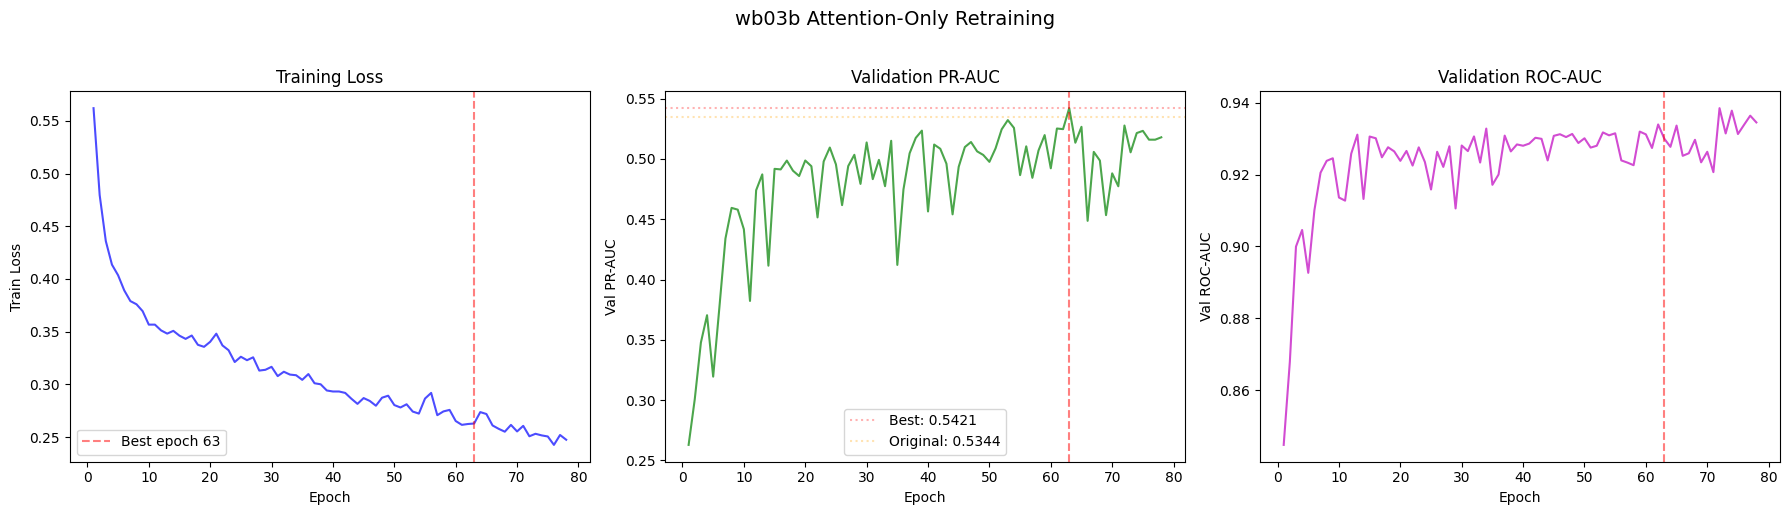

Saved → /run/media/ncarcasci/Volume/THESIS/results/wb03b/attention_retrain_curves.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(train_losses) + 1)

# Loss
axes[0].plot(epochs, train_losses, "b-", alpha=0.7)
axes[0].axvline(best_epoch, color="red", ls="--", alpha=0.5, label=f"Best epoch {best_epoch}")
axes[0].set(xlabel="Epoch", ylabel="Train Loss", title="Training Loss")
axes[0].legend()

# Val PR-AUC
axes[1].plot(epochs, val_pr_aucs, "g-", alpha=0.7)
axes[1].axvline(best_epoch, color="red", ls="--", alpha=0.5)
axes[1].axhline(best_val_pr, color="red", ls=":", alpha=0.3,
                label=f"Best: {best_val_pr:.4f}")
axes[1].axhline(ORIGINAL_METRICS["best_val_pr_auc"], color="orange", ls=":", alpha=0.3,
                label=f"Original: {ORIGINAL_METRICS['best_val_pr_auc']:.4f}")
axes[1].set(xlabel="Epoch", ylabel="Val PR-AUC", title="Validation PR-AUC")
axes[1].legend()

# Val ROC-AUC
axes[2].plot(epochs, val_roc_aucs, "m-", alpha=0.7)
axes[2].axvline(best_epoch, color="red", ls="--", alpha=0.5)
axes[2].set(xlabel="Epoch", ylabel="Val ROC-AUC", title="Validation ROC-AUC")

plt.suptitle("wb03b Attention-Only Retraining", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(WB03B_DIR / "attention_retrain_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {WB03B_DIR / 'attention_retrain_curves.png'}")